In [48]:
import kagglehub
import os
path=kagglehub.dataset_download("aniketyadav1/kmeans")
os.listdir(path)

Using Colab cache for faster access to the 'kmeans' dataset.


['k-means.csv']

In [53]:
import pandas as pd
df=pd.read_csv(os.path.join(path,"k-means.csv"))
df.head()

,name,age,income
0,Rob,27,70000
1,Michael,29,90000
2,Mohan,29,61000
3,Ismail,28,60000
4,Kory,42,150000


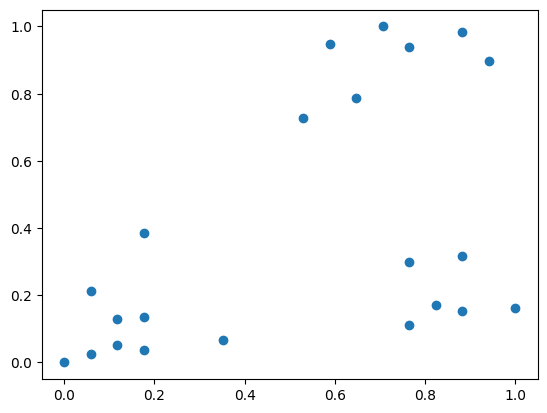

In [57]:
from matplotlib import pyplot as plt
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
scaler.fit(df[['income']])
df['income']=scaler.transform(df[['income']])

scaler.fit(df[['age']])
df['age']=scaler.transform(df[['age']])
plt.scatter(df['age'],df['income'])

In [58]:
from sklearn.cluster import KMeans
km=KMeans(n_clusters=3)
df['cluster']=km.fit_predict(df[['age','income']])

In [59]:
df1=df[df['cluster']==1]
df0=df[df['cluster']==0]
df2=df[df['cluster']==2]

/tmp/ipykernel_515/94933630.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


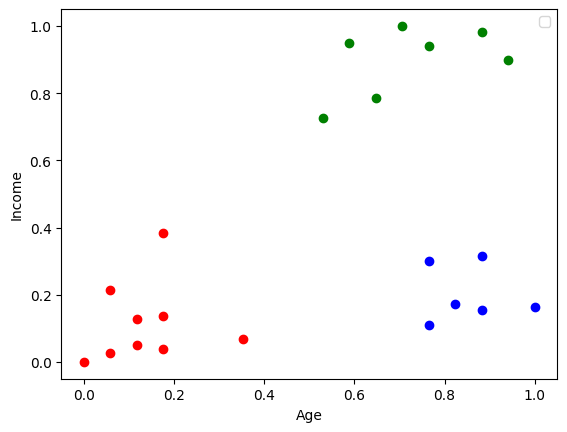

In [61]:

plt.xlabel("Age")
plt.ylabel("Income")
plt.scatter(df1['age'],df1['income'], color='green')
plt.scatter(df2['age'],df2['income'], color='blue')
plt.scatter(df0['age'],df0['income'], color='red')
plt.legend()

## Computing the right number for K
elbow plot

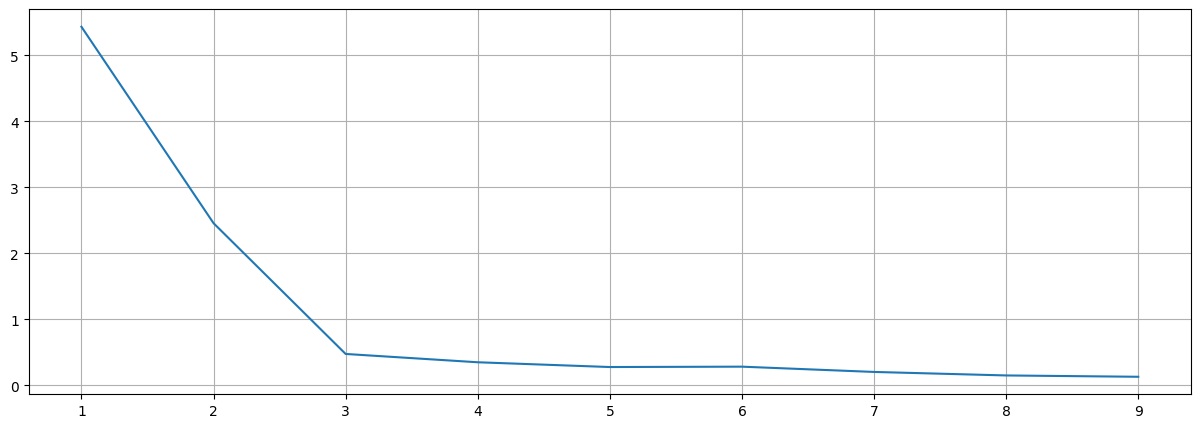

In [69]:
k_range=range(1,10)
sse=[]
for i in k_range:
    km=KMeans(n_clusters=i)
    km.fit(df[['age','income']])
    sse.append(km.inertia_)
plt.figure(figsize= (15,5))
plt.grid(visible=True,which='both')
plt.plot(k_range,sse)